# Sentence-Transformer Probe — Role & Feature Detection

Tests `all-MiniLM-L6-v2` on the real SonicWave spec to validate classifier quality
before wiring it into the FastAPI ingestion pipeline.

Run cells top-to-bottom. Cells 13–14 simulate the actual prompt filtering.

1. Can the model assign ROLE labels (CONTEXT / ACTOR / FEATURE / REQUIREMENT / ACCEPTANCE / NON_FUNCTIONAL / OUT_OF_SCOPE / GLOSSARY)?
2. Can it assign the right MODULE (Authentication, Payments, Music Streaming …)?
3. How does it compare against the keyword baseline?
4. Where does it fail — is the failure rate acceptable?

In [1]:
print("hello world")

hello world


In [2]:
# 1. Config — adjust SPEC_PATH if you want to test another spec
import pathlib

SPEC_PATH = pathlib.Path(
    r'D:/stage/testFlow/backend-2026/uploads/spec_texts/'
    r'1783678551052_SonicWave_Spec_Document.docx.txt'
)
ROLE_THRESHOLD      = 0.25   # cosine similarity below this -> UNTAGGED
MODULE_THRESHOLD    = 0.2
HEADING_PATH_WEIGHT = 0.40   # heading influence on module score

assert SPEC_PATH.exists(), f'Spec not found: {SPEC_PATH}'
print('Config OK — spec size:', SPEC_PATH.stat().st_size, 'bytes')

Config OK — spec size: 16003 bytes


In [3]:
# 2. Anchor descriptions for embedding comparison

ROLE_DESCRIPTIONS = {
    'CONTEXT': (
        'contexte, informations générales, présentation du projet, objectif, '
        'portée du document, description générale, introduction'
    ),

    'ACTOR': (
        'utilisateur, acteur, rôle, personne, intervenant, administrateur, '
        'client, visiteur, membre, opérateur'
    ),

    'FEATURE': (
        'fonctionnalité, capacité, module, écran, interface, workflow, '
        'processus métier, service proposé par le système'
    ),

    'REQUIREMENT': (
        'le système doit, doit permettre, exigence, obligation, contrainte '
        'fonctionnelle, comportement attendu, fonctionnalité requise'
    ),

    'ACCEPTANCE': (
        'critère d’acceptation, condition d’acceptation, scénario de test, '
        'étant donné lorsque alors, définition de terminé, condition de validation'
    ),

    'NON_FUNCTIONAL': (
        'performance, sécurité, fiabilité, disponibilité, évolutivité, '
        'accessibilité, temps de réponse, robustesse, maintenabilité'
    ),

    'OUT_OF_SCOPE': (
        'hors périmètre, hors scope, non inclus, exclu, version future, '
        'non pris en charge, ne sera pas implémenté'
    ),

    'GLOSSARY': (
        'glossaire, définition, terme, acronyme, abréviation, '
        'signifie, désigne, correspond à'
    ),
}
MODULE_DESCRIPTIONS = {
    'Authentication': (
        'authentification connexion déconnexion mot de passe inscription '
        'compte utilisateur session jeton jwt oauth permission rôle'
    ),

    'Search & Filtering': (
        'recherche filtre tri pagination parcourir résultats '
        'rechercher sélectionner'
    ),

    'Notifications': (
        'notification email sms alerte message push toast '
        'courriel rappel'
    ),

    'Reporting': (
        'rapport tableau de bord statistiques indicateurs '
        'analyse export pdf csv métriques'
    ),

    'Security': (
        'sécurité chiffrement cryptage csrf xss limitation de débit '
        'verrouillage authentification à deux facteurs 2fa'
    ),

    'Performance': (
        'performance temps de réponse latence disponibilité '
        'charge montée en charge rapidité timeout'
    ),

    'Accessibility': (
        'accessibilité lecteur d’écran navigation clavier '
        'contraste wcag aria'
    ),

    'Payments': (
        'paiement facture facturation abonnement commande '
        'encaissement stripe premium freemium'
    ),

    'Music Streaming': (
        'musique streaming lecture playlist morceau chanson '
        'album artiste audio lecture en continu'
    ),

    'Recommendations': (
        'recommandation suggestion personnalisation '
        'contenu recommandé découverte'
    ),

    'Offline Mode': (
        'mode hors ligne cache téléchargement synchronisation '
        'connexion indisponible'
    ),

    'Admin': (
        'administration administrateur configuration '
        'gestion modération panneau d’administration back-office'
    ),
}

print('Roles  :', list(ROLE_DESCRIPTIONS))
print('Modules:', list(MODULE_DESCRIPTIONS))

Roles  : ['CONTEXT', 'ACTOR', 'FEATURE', 'REQUIREMENT', 'ACCEPTANCE', 'NON_FUNCTIONAL', 'OUT_OF_SCOPE', 'GLOSSARY']
Modules: ['Authentication', 'Users', 'CRUD Operations', 'Search & Filtering', 'Notifications', 'Reporting', 'Security', 'Performance', 'Accessibility', 'Payments', 'Music Streaming', 'Recommendations', 'Offline Mode', 'Admin']


In [5]:
# 3. Load model (~90 MB download first run, cached afterwards)
import numpy as np
from sentence_transformers import SentenceTransformer

print('Loading model ...')
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print('Model ready.')

role_labels   = list(ROLE_DESCRIPTIONS)
module_labels = list(MODULE_DESCRIPTIONS)

role_anchors   = model.encode(list(ROLE_DESCRIPTIONS.values()),   normalize_embeddings=True)
module_anchors = model.encode(list(MODULE_DESCRIPTIONS.values()), normalize_embeddings=True)
print(f'Anchors: roles={role_anchors.shape}  modules={module_anchors.shape}')

Loading model ...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1958.65it/s]


Model ready.
Anchors: roles=(8, 1024)  modules=(14, 1024)


In [ ]:
# 4. Read spec and split into bullet/sentence Items
import re
from dataclasses import dataclass


@dataclass
class Item:
    id: str
    text: str
    heading: str = ''
    role: str = 'UNTAGGED'
    role_score: float = 0.0
    module: str = 'UNTAGGED'
    module_score: float = 0.0


def extract_items(path):
    raw = path.read_text(encoding='utf-8', errors='replace')
    lines = [ln.strip() for ln in raw.splitlines()]
    # a heading is a short digit-prefixed or ALL-CAPS line
    heading_re = re.compile(r'^(?:\d+(?:\.\d+)*\.?\s+\S|[A-Z][A-Z ]{4,}$)')
    bullet_re  = re.compile(r'^[-*]\s+|^\d+[.)\s]+')
    items, heading, idx = [], 'General', 0
    for line in lines:
        if not line or len(line) < 5:
            continue
        if heading_re.match(line) and len(line) < 120:
            heading = line
            continue
        if bullet_re.match(line):
            t = bullet_re.sub('', line).strip()
            if len(t) >= 10:
                items.append(Item(f'ITEM-{idx:04d}', t, heading))
                idx += 1
        else:
            for s in re.split(r'(?<=[.!?])\s+', line):
                s = s.strip()
                if len(s) >= 15:
                    items.append(Item(f'ITEM-{idx:04d}', s, heading))
                    idx += 1
    return items


items = extract_items(SPEC_PATH)
print(f'Total items extracted: {len(items)}')
print(items)

In [ ]:
# 5. Tag roles — single batched encode + cosine similarity
from collections import Counter

# Prepend heading as a soft prior
texts = [f'{it.heading}: {it.text}' for it in items]
vecs  = model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
sims  = vecs @ role_anchors.T   # shape (N_items, N_roles)

for it, row in zip(items, sims):
    best  = int(np.argmax(row))
    score = float(row[best])
    it.role       = role_labels[best] if score >= ROLE_THRESHOLD else 'UNTAGGED'
    it.role_score = score

role_dist = Counter(it.role for it in items)
print('Role distribution:')
for r, c in sorted(role_dist.items(), key=lambda x: -x[1]):
    print(f'  {r:<20} {c:>4}  ({c/len(items)*100:5.1f}%)')

In [ ]:
# 6. Tag modules — heading-weighted blend of content + heading similarities

cvecs = model.encode([it.text    for it in items], normalize_embeddings=True)
hvecs = model.encode([it.heading for it in items], normalize_embeddings=True)

blended = (
    (1 - HEADING_PATH_WEIGHT) * (cvecs @ module_anchors.T)
    + HEADING_PATH_WEIGHT     * (hvecs @ module_anchors.T)
)

for it, row in zip(items, blended):
    best  = int(np.argmax(row))
    score = float(row[best])
    it.module       = module_labels[best] if score >= MODULE_THRESHOLD else 'UNTAGGED'
    it.module_score = score

mod_dist = Counter(it.module for it in items)
print('Module distribution:')
for m, c in sorted(mod_dist.items(), key=lambda x: -x[1]):
    print(f'  {m:<25} {c:>4}  ({c/len(items)*100:5.1f}%)')

In [ ]:
# 7. Spot-check: top-5 items per ROLE (highest-confidence first)
import pandas as pd

pd.set_option('display.max_colwidth', 90)

df = pd.DataFrame([{
    'id':           it.id,
    'heading':      it.heading[:40],
    'text':         it.text[:88],
    'role':         it.role,
    'role_score':   round(it.role_score, 3),
    'module':       it.module,
    'module_score': round(it.module_score, 3),
} for it in items])

SEP = chr(9472) * 100
for role in ['FEATURE','REQUIREMENT','ACCEPTANCE','NON_FUNCTIONAL',
             'ACTOR','OUT_OF_SCOPE','GLOSSARY','CONTEXT','UNTAGGED']:
    sub = df[df.role == role].nlargest(5, 'role_score')
    if sub.empty:
        continue
    print(f'\n{SEP}\n  ROLE = {role}\n{SEP}')
    print(sub[['role_score', 'module', 'text']].to_string(index=False))

In [ ]:
# 8. Spot-check: top-5 items per MODULE
SEP = chr(9472) * 100
for mod in module_labels + ['UNTAGGED']:
    sub = df[df.module == mod].nlargest(5, 'module_score')
    if sub.empty:
        continue
    print(f'\n{SEP}\n  MODULE = {mod}\n{SEP}')
    print(sub[['module_score', 'role', 'heading', 'text']].to_string(index=False))

In [ ]:
# 9. Keyword baseline vs embedding
KEYWORD_MAP = {
    'Authentication':     ('login','logout','password','oauth','jwt','session',
                           'authentification','inscription','compte'),
    'Search & Filtering': ('search','filter','sort','paginate','recherche','filtrer'),
    'Notifications':      ('notification','email','sms','toast','alert'),
    'Reporting':          ('report','export','dashboard','analytics','statistiques'),
    'Security':           ('security','csrf','xss','encryption','lockout','2fa','securite'),
    'Performance':        ('performance','latency','timeout','load','latence','disponibilite'),
    'Accessibility':      ('accessibility','aria','keyboard','contrast','accessibilite'),
    'Payments':           ('payment','billing','checkout','paiement','abonnement','premium','freemium'),
    'Music Streaming':    ('stream','playlist','track','audio','musique','piste','lecture','ecoute'),
    'Recommendations':    ('recommendation','algorithm','recommandation','suggestion'),
    'Offline Mode':       ('offline','hors-ligne','cache','download','telecharg'),
    'Admin':              ('admin','moderation','back-office','administration'),
}

def kw_classify(text):
    t = text.lower()
    for mod, keys in KEYWORD_MAP.items():
        if any(k in t for k in keys):
            return mod
    return 'UNTAGGED'

df['module_kw'] = df['text'].apply(kw_classify)
agreed = (df.module == df.module_kw).sum()
print(f'Embedding vs keyword agreement: {agreed}/{len(df)} = {agreed/len(df)*100:.1f}%')

disagree = df[df.module != df.module_kw][['text','module','module_kw','module_score']]
print(f'\nDisagreements: {len(disagree)} (first 20):')
print(disagree.head(20).to_string(index=False))

In [ ]:
# 10. Heatmap: sample items vs role anchors
import matplotlib.pyplot as plt
import seaborn as sns

sample_df = (
    df[df.role != 'UNTAGGED']
    .groupby('role')
    .apply(lambda g: g.nlargest(2, 'role_score'), include_groups=False)
    .reset_index(level=0)
)
stexts  = sample_df['text'].tolist()
slabels = [f"{row.role}|{row.text[:28]}" for _, row in sample_df.iterrows()]

sv  = model.encode(stexts, normalize_embeddings=True)
sim = sv @ role_anchors.T

fig, ax = plt.subplots(figsize=(13, max(6, len(stexts) * 0.46)))
sns.heatmap(sim, xticklabels=role_labels, yticklabels=slabels,
            annot=True, fmt='.2f', cmap='Blues', vmin=0.1, vmax=0.65, ax=ax)
ax.set_title(
    'Cosine similarity: sample items x role anchors\n'
    '(the max value in each row should be under the CORRECT role column)'
)
plt.tight_layout()
plt.show()

In [ ]:
# 11. Threshold sweep — find best ROLE_THRESHOLD
scores     = np.array([it.role_score for it in items])
thresholds = np.arange(0.15, 0.55, 0.025)

rows = [
    {
        'threshold':  round(t, 3),
        'untagged_%': round((scores < t).mean() * 100, 1),
        'mean_conf':  round(scores[scores >= t].mean(), 3) if (scores >= t).any() else 0,
    }
    for t in thresholds
]
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(sweep.threshold, sweep['untagged_%'], 'r-o', label='UNTAGGED %')
ax2.plot(sweep.threshold, sweep['mean_conf'],  'b-s', label='mean confidence')
ax1.axhline(10, color='red',  linestyle='--', alpha=0.5, label='10% target')
ax1.axvline(ROLE_THRESHOLD, color='gray', linestyle=':', label=f'current={ROLE_THRESHOLD}')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('UNTAGGED %', color='red')
ax2.set_ylabel('Mean confidence (tagged items)', color='blue')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.set_title('Threshold sweep: UNTAGGED % vs confidence')
plt.tight_layout()
plt.show()

In [ ]:
# 12. UNTAGGED inspection
untagged_df = df[df.role == 'UNTAGGED'].sort_values('role_score', ascending=False)
print(f'UNTAGGED: {len(untagged_df)}/{len(df)} ({len(untagged_df)/len(df)*100:.1f}%)')
if not untagged_df.empty:
    print('\nSample (closest to threshold, easiest to rescue):')
    print(untagged_df.head(20)[['role_score','heading','text']].to_string(index=False))

In [ ]:
# 13. Simulate generate-plan filtering
# Roles needed for plan generation: CONTEXT, FEATURE, ACTOR
PLAN_ROLES   = {'CONTEXT', 'FEATURE', 'ACTOR'}
BUDGET_CHARS = 6_000

filtered = [
    it for it in sorted(items, key=lambda x: -x.role_score)
    if it.role in PLAN_ROLES
]
budget, total = [], 0
for it in filtered:
    if total + len(it.text) > BUDGET_CHARS:
        break
    budget.append(it)
    total += len(it.text)

spec_size = SPEC_PATH.stat().st_size
print(f'Items matching PLAN roles : {len(filtered)}/{len(items)}')
print(f'After budget trim         : {len(budget)} items  ({total} chars)')
print(f'Raw spec bytes            : {spec_size:,}')
print(f'Compression               : {total/spec_size*100:.1f}%')
print('\nFiltered context (first 20):')
for it in budget[:20]:
    print(f'  [{it.role:<15} {it.role_score:.2f}]  {it.text[:80]}')

In [ ]:
# 14. Simulate generate-test-cases filtering (module-scoped)
# Change TARGET_MODULE to test other feature areas
CASE_ROLES    = {'FEATURE', 'REQUIREMENT', 'ACCEPTANCE'}
TARGET_MODULE = 'Authentication'   # <-- edit me
BUDGET_CHARS  = 8_000

filtered_c = [
    it for it in sorted(items, key=lambda x: -x.role_score)
    if (
        it.role in CASE_ROLES and it.module == TARGET_MODULE
        or it.role in {'CONTEXT', 'ACTOR'}   # global context always included
    )
]
budget_c, total_c = [], 0
for it in filtered_c:
    if total_c + len(it.text) > BUDGET_CHARS:
        break
    budget_c.append(it)
    total_c += len(it.text)

print(f'Module scope : {TARGET_MODULE!r}')
print(f'Scoped items : {len(filtered_c)} -> after budget: {len(budget_c)} ({total_c} chars)')
print('\nScoped context (first 20):')
for it in budget_c[:20]:
    print(f'  [{it.role:<15}|{it.module:<20}|{it.role_score:.2f}]  {it.text[:68]}')

In [ ]:
# 15. Final verdict
u_pct  = role_dist.get('UNTAGGED', 0) / len(items) * 100
mu_pct = mod_dist.get('UNTAGGED',  0) / len(items) * 100
ok_role   = u_pct  < 15
ok_module = mu_pct < 20

print('=' * 58)
print('VERDICT')
print('=' * 58)
print(f'Total items          : {len(items)}')
print(f'Role  UNTAGGED       : {role_dist.get("UNTAGGED",0):>4}  ({u_pct:.1f}%)  '
      f'{"OK" if ok_role else "HIGH — lower ROLE_THRESHOLD"}')
print(f'Module UNTAGGED      : {mod_dist.get("UNTAGGED",0):>4}  ({mu_pct:.1f}%)  '
      f'{"OK" if ok_module else "HIGH — lower MODULE_THRESHOLD"}')
print(f'Keyword agreement    : {agreed}/{len(df)}  ({agreed/len(df)*100:.1f}%)')
print(f'Plan context size    : {total} chars  (raw: {spec_size:,} bytes)')
print()
if ok_role and ok_module:
    print('Approach looks viable -- proceed to Phase 1 of the implementation plan.')
else:
    print('Review threshold sweep (cell 11) and adjust thresholds before proceeding.')

In [6]:
# ── CELL A: Ground Truth (manually labeled from the SonicWave spec) ───────────
# role values: CONTEXT ACTOR FEATURE REQUIREMENT ACCEPTANCE NON_FUNCTIONAL OUT_OF_SCOPE GLOSSARY
# module values must match MODULE_DESCRIPTIONS keys exactly

GROUND_TRUTH = [
    # ── CONTEXT ──────────────────────────────────────────────────────────────
    {"text": "SonicWave est une plateforme de streaming musical permettant aux utilisateurs d'écouter, organiser et découvrir de la musique en ligne et hors ligne.",
     "role": "CONTEXT", "module": "Music Streaming"},
    {"text": "Ce document sert de référence unique pour les équipes de développement, de design et d'assurance qualité.",
     "role": "CONTEXT", "module": "Music Streaming"},
    {"text": "SonicWave couvre les applications suivantes : Application mobile (iOS / Android), Application web, Application desktop, Back-office d'administration.",
     "role": "CONTEXT", "module": "Music Streaming"},
    {"text": "SonicWave repose sur une architecture orientée microservices, découplant les responsabilités métier pour permettre un déploiement et un scaling indépendants.",
     "role": "CONTEXT", "module": "Performance"},
    {"text": "Le stockage audio doit respecter les accords de licence avec les labels (durée de rétention, territoires autorisés).",
     "role": "CONTEXT", "module": "Music Streaming"},
    {"text": "Le catalogue musical est fourni et mis à jour par des partenaires labels/artistes existants.",
     "role": "CONTEXT", "module": "Music Streaming"},

    # ── ACTOR ─────────────────────────────────────────────────────────────────
    {"text": "Visiteur : Non authentifié. Peut écouter en aperçu (30s) et s'inscrire.",
     "role": "ACTOR", "module": "Authentication"},
    {"text": "Utilisateur Free : Compte gratuit. Écoute avec publicité, playlists limitées.",
     "role": "ACTOR", "module": "Music Streaming"},
    {"text": "Utilisateur Premium : Abonné payant. Écoute illimitée sans pub, mode hors-ligne, qualité HD.",
     "role": "ACTOR", "module": "Payments"},
    {"text": "Artiste / Label : Compte fournisseur de contenu. Upload de titres, statistiques d'écoute, gestion profil.",
     "role": "ACTOR", "module": "Reporting"},
    {"text": "Administrateur : Équipe interne SonicWave. Modération contenu, gestion utilisateurs, configuration.",
     "role": "ACTOR", "module": "Admin"},
    {"text": "Support client : Équipe interne. Consultation tickets, remboursements, assistance compte.",
     "role": "ACTOR", "module": "Admin"},
    {"text": "Équipe QA / TestFlow : Base de génération du plan de test.",
     "role": "ACTOR", "module": "Music Streaming"},

    # ── GLOSSARY ──────────────────────────────────────────────────────────────
    {"text": "DRM : Digital Rights Management — protection des contenus audio.",
     "role": "GLOSSARY", "module": "Security"},
    {"text": "CDN : Content Delivery Network — réseau de diffusion de contenu.",
     "role": "GLOSSARY", "module": "Performance"},
    {"text": "Freemium : Modèle avec offre gratuite limitée et offre payante.",
     "role": "GLOSSARY", "module": "Payments"},
    {"text": "Playlist collaborative : Playlist modifiable par plusieurs utilisateurs.",
     "role": "GLOSSARY", "module": "Music Streaming"},
    {"text": "Crossfade : Fondu enchaîné entre deux pistes audio.",
     "role": "GLOSSARY", "module": "Music Streaming"},

    # ── OUT_OF_SCOPE ──────────────────────────────────────────────────────────
    {"text": "Sont explicitement exclus de cette version : la diffusion de contenu vidéo, les podcasts en direct (live), et la billetterie d'événements.",
     "role": "OUT_OF_SCOPE", "module": "Music Streaming"},
    {"text": "La bande passante CDN est plafonnée par les contrats fournisseurs en vigueur.",
     "role": "OUT_OF_SCOPE", "module": "Performance"},

    # ── REQUIREMENT — Authentication ──────────────────────────────────────────
    {"text": "L'utilisateur peut créer un compte via email/mot de passe ou OAuth (Google, Facebook, Apple).",
     "role": "REQUIREMENT", "module": "Authentication"},
    {"text": "L'utilisateur peut réinitialiser son mot de passe via lien envoyé par email (validité 24h).",
     "role": "REQUIREMENT", "module": "Authentication"},
    {"text": "Le système applique une politique de mot de passe (min. 8 caractères, 1 majuscule, 1 chiffre).",
     "role": "REQUIREMENT", "module": "Authentication"},
    {"text": "L'utilisateur peut activer l'authentification à deux facteurs (2FA).",
     "role": "REQUIREMENT", "module": "Authentication"},
    {"text": "Le système verrouille le compte après 5 tentatives de connexion échouées (15 min).",
     "role": "REQUIREMENT", "module": "Security"},
    {"text": "L'utilisateur peut se connecter simultanément sur maximum 5 appareils.",
     "role": "REQUIREMENT", "module": "Authentication"},
    {"text": "L'utilisateur peut supprimer définitivement son compte (RGPD).",
     "role": "REQUIREMENT", "module": "Authentication"},

    # ── REQUIREMENT — Search ──────────────────────────────────────────────────
    {"text": "L'utilisateur peut rechercher par titre, artiste, album ou playlist.",
     "role": "REQUIREMENT", "module": "Search & Filtering"},
    {"text": "La recherche propose des suggestions en temps réel (dès 2 caractères saisis).",
     "role": "REQUIREMENT", "module": "Search & Filtering"},
    {"text": "Les résultats sont filtrables par type (piste, album, artiste, playlist, podcast).",
     "role": "REQUIREMENT", "module": "Search & Filtering"},
    {"text": "Le système tolère les fautes de frappe (recherche floue).",
     "role": "REQUIREMENT", "module": "Search & Filtering"},
    {"text": "L'historique des 20 dernières recherches est conservé et consultable.",
     "role": "REQUIREMENT", "module": "Search & Filtering"},

    # ── REQUIREMENT — Music Streaming ─────────────────────────────────────────
    {"text": "L'utilisateur peut lire, mettre en pause, avancer et reculer une piste.",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "Le système propose 3 niveaux de qualité audio : Normale (96kbps), Haute (160kbps), Très Haute (320kbps, Premium uniquement).",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "Le lecteur applique un crossfade configurable (0 à 12 secondes) entre les pistes.",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "L'utilisateur Free entend une publicité audio toutes les 3 à 5 pistes.",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "Le système reprend la lecture à la position exacte après interruption (appel, changement d'app).",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "L'utilisateur peut activer un mode lecture aléatoire (shuffle) et répétition (piste/liste).",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "L'utilisateur peut créer, renommer et supprimer des playlists.",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "L'utilisateur peut rendre une playlist collaborative (édition multi-utilisateurs).",
     "role": "REQUIREMENT", "module": "Music Streaming"},
    {"text": "La bibliothèque personnelle est synchronisée entre tous les appareils de l'utilisateur.",
     "role": "REQUIREMENT", "module": "Music Streaming"},

    # ── REQUIREMENT — Offline / Recommendations / Payments / Admin ────────────
    {"text": "L'utilisateur Premium peut télécharger des pistes/playlists pour écoute hors-ligne.",
     "role": "REQUIREMENT", "module": "Offline Mode"},
    {"text": "Le système génère une playlist hebdomadaire personnalisée (Découvertes).",
     "role": "REQUIREMENT", "module": "Recommendations"},
    {"text": "La page d'accueil affiche des suggestions basées sur l'historique d'écoute.",
     "role": "REQUIREMENT", "module": "Recommendations"},
    {"text": "Le système propose des radios thématiques générées à partir d'une piste ou d'un artiste.",
     "role": "REQUIREMENT", "module": "Recommendations"},
    {"text": "L'utilisateur peut souscrire à un abonnement Premium (mensuel ou annuel).",
     "role": "REQUIREMENT", "module": "Payments"},
    {"text": "Le système supporte les paiements par carte bancaire, PayPal et paiement mobile.",
     "role": "REQUIREMENT", "module": "Payments"},
    {"text": "L'utilisateur peut annuler son abonnement à tout moment (effectif à la fin de la période payée).",
     "role": "REQUIREMENT", "module": "Payments"},
    {"text": "Le système gère les échecs de paiement avec 3 tentatives de relance avant suspension Premium.",
     "role": "REQUIREMENT", "module": "Payments"},
    {"text": "L'artiste peut uploader des titres et albums avec métadonnées (genre, date, pochette).",
     "role": "REQUIREMENT", "module": "Admin"},
    {"text": "L'artiste peut consulter des statistiques d'écoute (nombre d'écoutes, provenance géographique).",
     "role": "REQUIREMENT", "module": "Reporting"},
    {"text": "L'administrateur peut suspendre ou supprimer un compte utilisateur/artiste.",
     "role": "REQUIREMENT", "module": "Admin"},
    {"text": "Le système envoie une facture par email après chaque paiement.",
     "role": "REQUIREMENT", "module": "Notifications"},

    # ── NON_FUNCTIONAL ────────────────────────────────────────────────────────
    {"text": "Temps de chargement initial de l'application < 2 secondes.",
     "role": "NON_FUNCTIONAL", "module": "Performance"},
    {"text": "Latence de démarrage de lecture audio < 1,5 seconde.",
     "role": "NON_FUNCTIONAL", "module": "Performance"},
    {"text": "Le système supporte 5 millions d'utilisateurs simultanés avec dégradation gracieuse au-delà.",
     "role": "NON_FUNCTIONAL", "module": "Performance"},
    {"text": "Les résultats de recherche s'affichent en moins de 500 ms (P95).",
     "role": "NON_FUNCTIONAL", "module": "Performance"},
    {"text": "Toutes les communications sont chiffrées via TLS 1.3.",
     "role": "NON_FUNCTIONAL", "module": "Security"},
    {"text": "Les mots de passe sont stockés hashés (bcrypt ou équivalent), jamais en clair.",
     "role": "NON_FUNCTIONAL", "module": "Security"},
    {"text": "Le contenu audio est protégé par DRM pour empêcher le téléchargement non autorisé.",
     "role": "NON_FUNCTIONAL", "module": "Security"},
    {"text": "Le système est conforme au RGPD pour les utilisateurs de l'Union Européenne.",
     "role": "NON_FUNCTIONAL", "module": "Security"},
    {"text": "Disponibilité du service >= 99,9 % (SLA mensuel).",
     "role": "NON_FUNCTIONAL", "module": "Performance"},
    {"text": "Reprise automatique après panne (failover) en moins de 60 secondes.",
     "role": "NON_FUNCTIONAL", "module": "Performance"},
    {"text": "Conformité WCAG 2.1 niveau AA pour l'application web.",
     "role": "NON_FUNCTIONAL", "module": "Accessibility"},
    {"text": "Support des lecteurs d'écran (VoiceOver, TalkBack).",
     "role": "NON_FUNCTIONAL", "module": "Accessibility"},
    {"text": "Contraste de couleurs minimum 4,5:1 pour le texte standard.",
     "role": "NON_FUNCTIONAL", "module": "Accessibility"},
    {"text": "L'architecture doit permettre un scaling horizontal des services de streaming et de recommandation via Kubernetes.",
     "role": "NON_FUNCTIONAL", "module": "Performance"},

    # ── ACCEPTANCE ────────────────────────────────────────────────────────────
    {"text": "Post-condition UC-01 : Compte créé avec statut Free, session active.",
     "role": "ACCEPTANCE", "module": "Authentication"},
    {"text": "Scénario d'erreur UC-01 : Email déjà utilisé — message d'erreur explicite, proposition de connexion.",
     "role": "ACCEPTANCE", "module": "Authentication"},
    {"text": "Scénario nominal UC-02 : L'utilisateur active le mode avion, lance la lecture depuis sa bibliothèque téléchargée, la piste se lit sans connexion réseau.",
     "role": "ACCEPTANCE", "module": "Offline Mode"},
    {"text": "Scénario d'erreur UC-02 : Licence DRM expirée (piste non synchronisée depuis 30 jours) — piste grisée, message invitant à se reconnecter.",
     "role": "ACCEPTANCE", "module": "Offline Mode"},
    {"text": "Post-condition UC-04 : Publicités désactivées, qualité audio HD disponible, téléchargement hors-ligne débloqué.",
     "role": "ACCEPTANCE", "module": "Payments"},
    {"text": "Toutes les exigences Priorité Haute doivent disposer d'au moins un scénario de test nominal et un scénario d'erreur.",
     "role": "ACCEPTANCE", "module": "Music Streaming"},
    {"text": "Les parcours critiques (inscription, paiement, lecture audio) doivent être couverts par des tests de bout en bout.",
     "role": "ACCEPTANCE", "module": "Music Streaming"},
    {"text": "Les cas limites (paiement échoué, DRM expiré, compte verrouillé) doivent être explicitement testés.",
     "role": "ACCEPTANCE", "module": "Payments"},
]

print(f"Ground truth size: {len(GROUND_TRUTH)} items")

from collections import Counter

print("\nRole distribution:")
for r, c in Counter(gt['role'] for gt in GROUND_TRUTH).most_common():
    print(f"  {r:<20} {c}")
print("\nModule distribution:")
for m, c in Counter(gt['module'] for gt in GROUND_TRUTH).most_common():
    print(f"  {m:<25} {c}")


Ground truth size: 75 items

Role distribution:
  REQUIREMENT          33
  NON_FUNCTIONAL       14
  ACCEPTANCE           8
  ACTOR                7
  CONTEXT              6
  GLOSSARY             5
  OUT_OF_SCOPE         2

Module distribution:
  Music Streaming           21
  Performance               10
  Authentication            9
  Payments                  8
  Security                  6
  Search & Filtering        5
  Admin                     4
  Offline Mode              3
  Recommendations           3
  Accessibility             3
  Reporting                 2
  Notifications             1


In [8]:
# ── CELL B: Run classifier on ground truth items ──────────────────────────────
# Requires: model, role_anchors, module_anchors, role_labels, module_labels,
#           ROLE_THRESHOLD, MODULE_THRESHOLD, HEADING_PATH_WEIGHT
# (from your setup cells)

import numpy as np
import pandas as pd

gt_texts = [gt["text"] for gt in GROUND_TRUTH]

# Encode all ground truth texts (no heading available → use text only)
gt_vecs = model.encode(gt_texts, normalize_embeddings=True, show_progress_bar=False)

# Role predictions
role_sims = gt_vecs @ role_anchors.T          # (N, n_roles)
mod_sims  = gt_vecs @ module_anchors.T        # (N, n_modules)

results = []
for i, gt in enumerate(GROUND_TRUTH):
    r_best  = int(np.argmax(role_sims[i]));  r_score = float(role_sims[i][r_best])
    m_best  = int(np.argmax(mod_sims[i]));   m_score = float(mod_sims[i][m_best])

    pred_role   = role_labels[r_best]   if r_score  >= ROLE_THRESHOLD   else "UNTAGGED"
    pred_module = module_labels[m_best] if m_score  >= MODULE_THRESHOLD  else "UNTAGGED"

    results.append({
        "text":        gt["text"][:80],
        "true_role":   gt["role"],
        "pred_role":   pred_role,
        "role_score":  round(r_score, 3),
        "role_ok":     pred_role == gt["role"],
        "true_module": gt["module"],
        "pred_module": pred_module,
        "mod_score":   round(m_score, 3),
        "mod_ok":      pred_module == gt["module"],
    })

df_eval = pd.DataFrame(results)
pd.set_option("display.max_colwidth", 82)
print(df_eval[["true_role","pred_role","role_ok","true_module","pred_module","mod_ok","role_score","mod_score"]].to_string())


         true_role       pred_role  role_ok         true_module         pred_module  mod_ok  role_score  mod_score
0          CONTEXT        UNTAGGED    False     Music Streaming     Music Streaming    True       0.208      0.571
1          CONTEXT         CONTEXT     True     Music Streaming           Reporting   False       0.398      0.281
2          CONTEXT         FEATURE    False     Music Streaming               Admin   False       0.371      0.305
3          CONTEXT         FEATURE    False         Performance         Performance    True       0.453      0.216
4          CONTEXT        UNTAGGED    False     Music Streaming     Music Streaming    True       0.233      0.292
5          CONTEXT        UNTAGGED    False     Music Streaming     Music Streaming    True       0.207      0.452
6            ACTOR           ACTOR     True      Authentication      Authentication    True       0.305      0.388
7            ACTOR        UNTAGGED    False     Music Streaming     Music Stream

ACCURACY REPORT
  Items evaluated     : 75
  Role  accuracy      :  13.3%  (UNTAGGED: 49.3%)
  Module accuracy     :  50.7%  (UNTAGGED: 0.0%)
  Both correct        :   5.3%

Per-role accuracy:
  ACCEPTANCE            37.5%  score=0.344  ███████
  ACTOR                 42.9%  score=0.296  ████████
  CONTEXT               16.7%  score=0.312  ███
  GLOSSARY               0.0%  score=0.174  
  NON_FUNCTIONAL         7.1%  score=0.230  █
  OUT_OF_SCOPE         100.0%  score=0.324  ████████████████████
  REQUIREMENT            0.0%  score=0.243  

Per-module accuracy:
  Accessibility             100.0%  score=0.292  ████████████████████
  Admin                      75.0%  score=0.451  ███████████████
  Authentication             44.4%  score=0.469  ████████
  Music Streaming            47.6%  score=0.350  █████████
  Notifications               0.0%  score=0.630  
  Offline Mode               66.7%  score=0.458  █████████████
  Payments                   75.0%  score=0.438  ███████████████
 

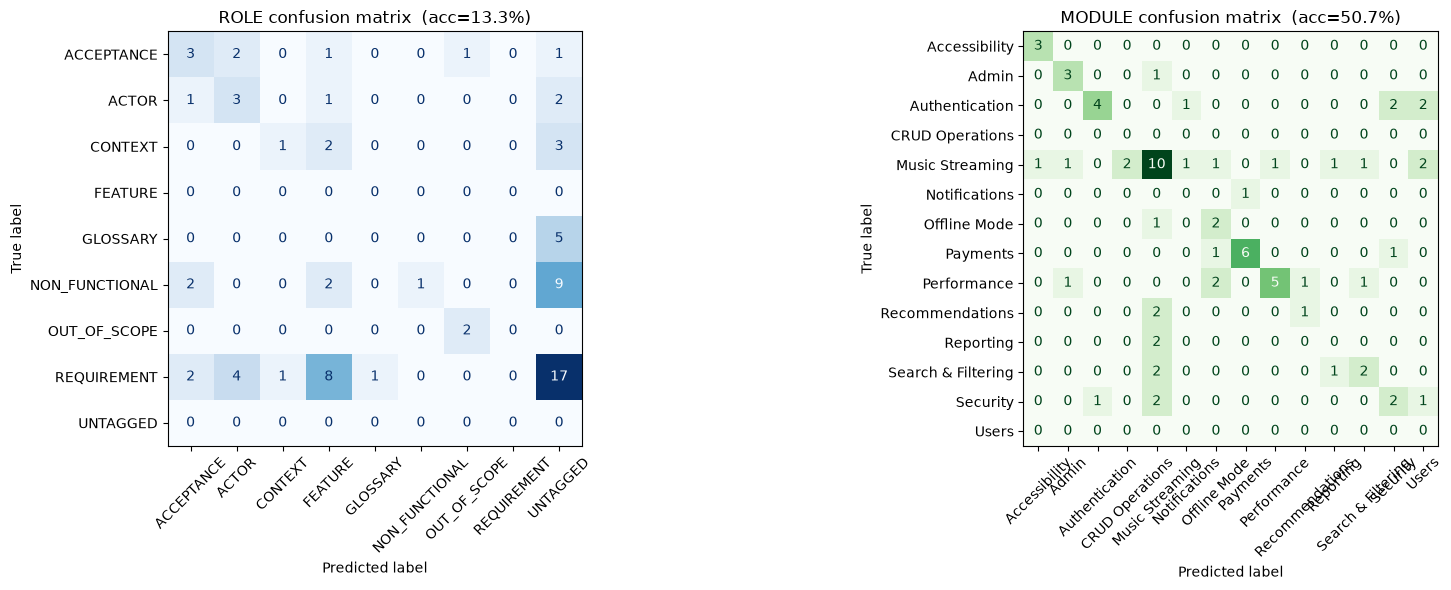


────────────────────────────────────────────────────────────────────────────────────────────────────
ROLE ERRORS (65 / 75)
────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                            text      true_role    pred_role  role_score
SonicWave est une plateforme de streaming musical permettant aux utilisateurs d'        CONTEXT     UNTAGGED       0.208
SonicWave couvre les applications suivantes : Application mobile (iOS / Android)        CONTEXT      FEATURE       0.371
SonicWave repose sur une architecture orientée microservices, découplant les res        CONTEXT      FEATURE       0.453
Le stockage audio doit respecter les accords de licence avec les labels (durée d        CONTEXT     UNTAGGED       0.233
Le catalogue musical est fourni et mis à jour par des partenaires labels/artiste        CONTEXT     UNTAGGED       0.207
   Utilisateur Free : Compte gratuit. Écoute avec

In [9]:
# ── CELL C: Accuracy report + confusion + error drill-down ───────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

n = len(df_eval)
role_acc = df_eval["role_ok"].mean() * 100
mod_acc  = df_eval["mod_ok"].mean()  * 100
both_acc = (df_eval["role_ok"] & df_eval["mod_ok"]).mean() * 100
untagged_role = (df_eval["pred_role"]   == "UNTAGGED").mean() * 100
untagged_mod  = (df_eval["pred_module"] == "UNTAGGED").mean() * 100

print("=" * 58)
print("ACCURACY REPORT")
print("=" * 58)
print(f"  Items evaluated     : {n}")
print(f"  Role  accuracy      : {role_acc:5.1f}%  (UNTAGGED: {untagged_role:.1f}%)")
print(f"  Module accuracy     : {mod_acc:5.1f}%  (UNTAGGED: {untagged_mod:.1f}%)")
print(f"  Both correct        : {both_acc:5.1f}%")

# ── Per-role accuracy ────────────────────────────────────────────────────────
print("\nPer-role accuracy:")
for role in sorted(df_eval["true_role"].unique()):
    sub = df_eval[df_eval["true_role"] == role]
    acc = sub["role_ok"].mean() * 100
    avg_score = sub["role_score"].mean()
    bar = "█" * int(acc / 5)
    print(f"  {role:<20} {acc:5.1f}%  score={avg_score:.3f}  {bar}")

# ── Per-module accuracy ───────────────────────────────────────────────────────
print("\nPer-module accuracy:")
for mod in sorted(df_eval["true_module"].unique()):
    sub = df_eval[df_eval["true_module"] == mod]
    acc = sub["mod_ok"].mean() * 100
    avg_score = sub["mod_score"].mean()
    bar = "█" * int(acc / 5)
    print(f"  {mod:<25} {acc:5.1f}%  score={avg_score:.3f}  {bar}")

# ── Confusion matrix — ROLE ───────────────────────────────────────────────────
all_roles = sorted(set(df_eval["true_role"]) | set(df_eval["pred_role"]))
cm_role = confusion_matrix(df_eval["true_role"], df_eval["pred_role"], labels=all_roles)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

disp = ConfusionMatrixDisplay(cm_role, display_labels=all_roles)
disp.plot(ax=axes[0], colorbar=False, xticks_rotation=45, cmap="Blues")
axes[0].set_title(f"ROLE confusion matrix  (acc={role_acc:.1f}%)", fontsize=12)

# ── Confusion matrix — MODULE ─────────────────────────────────────────────────
all_mods = sorted(set(df_eval["true_module"]) | set(df_eval["pred_module"]))
cm_mod = confusion_matrix(df_eval["true_module"], df_eval["pred_module"], labels=all_mods)

disp2 = ConfusionMatrixDisplay(cm_mod, display_labels=all_mods)
disp2.plot(ax=axes[1], colorbar=False, xticks_rotation=45, cmap="Greens")
axes[1].set_title(f"MODULE confusion matrix  (acc={mod_acc:.1f}%)", fontsize=12)

plt.tight_layout()
plt.show()

# ── Role errors: what did it predict instead? ─────────────────────────────────
role_errors = df_eval[~df_eval["role_ok"]][["text","true_role","pred_role","role_score"]]
mod_errors  = df_eval[~df_eval["mod_ok"]][["text","true_module","pred_module","mod_score"]]

if not role_errors.empty:
    print(f"\n{'─'*100}\nROLE ERRORS ({len(role_errors)} / {n})\n{'─'*100}")
    print(role_errors.to_string(index=False))

if not mod_errors.empty:
    print(f"\n{'─'*100}\nMODULE ERRORS ({len(mod_errors)} / {n})\n{'─'*100}")
    print(mod_errors.to_string(index=False))

# ── Final verdict ─────────────────────────────────────────────────────────────
print(f"\n{'='*58}")
print("VERDICT")
print(f"{'='*58}")
if role_acc >= 75 and mod_acc >= 65:
    print(f"  Role {role_acc:.0f}% / Module {mod_acc:.0f}% — GOOD. Proceed to Phase 1.")
elif role_acc >= 60:
    print(f"  Role {role_acc:.0f}% / Module {mod_acc:.0f}% — ACCEPTABLE. Tune descriptions before Phase 1.")
else:
    print(f"  Role {role_acc:.0f}% / Module {mod_acc:.0f}% — LOW. Revise anchor descriptions.")


In [6]:
import sentencepiece

print(sentencepiece.__version__)

0.2.2


In [12]:
# ── CELL D: Hybrid classifier config ─────────────────────────────────────────
# Edit ROLE_LEXICAL_RULES and MODULE_KEYWORDS freely — each entry is labelled.
# All patterns checked in ORDER; first match wins.

# ── ROLE: regex rules ─────────────────────────────────────────────────────────
# method = 'lexical' when a rule fires; 'embedding' otherwise
# ORDER: ACCEPTANCE first (most specific), then NON_FUNCTIONAL, then REQUIREMENT

ROLE_LEXICAL_RULES = [
    # --- ACCEPTANCE ---
    # UC-N anchor is very specific; no false positive risk
    ("ACCEPTANCE", re.compile(
        r"(scénario\s+(nominal|d.erreur)|post-condition|pré-condition)\s*(uc-?\d+|:)",
        re.IGNORECASE
    )),

    # --- NON_FUNCTIONAL ---
    # sub-pattern 1: numeric value + physical unit
    ("NON_FUNCTIONAL", re.compile(
        r"\d[\d\s,\.]*\s*(secondes?|ms|kbps|Go|Mo|Ko)\b",
        re.IGNORECASE
    )),
    # sub-pattern 2: comparison operator + percentage
    ("NON_FUNCTIONAL", re.compile(
        r"[<>=]{1,2}\s*\d[\d,\.]*\s*%"
    )),
    # sub-pattern 3: technical/infra keywords
    # ⚠️ DRM: safe here because ACCEPTANCE is checked first (catches "DRM expirée" via UC-N)
    # ⚠️ RGPD excluded: appears in REQUIREMENT context ("supprimer son compte (RGPD)")
    ("NON_FUNCTIONAL", re.compile(
        r"\b(P9[0-9]|SLA|TLS|WCAG|failover|Kubernetes|VoiceOver|TalkBack|bcrypt|hash[eé]s?|DRM)\b",
        re.IGNORECASE
    )),
    # sub-pattern 4: ratio pattern (e.g. 4,5:1 contrast)
    ("NON_FUNCTIONAL", re.compile(
        r"\d[\d,\.]+:\d+"
    )),
    # sub-pattern 5: capacity scale ("5 millions d'utilisateurs")
    ("NON_FUNCTIONAL", re.compile(
        r"\d[\d\s,\.]*\s+millions?\b",
        re.IGNORECASE
    )),

    # --- REQUIREMENT ---
    # Actor + modal verb  (utilisateur/artiste/administrateur/visiteur/système + peut/doit)
    ("REQUIREMENT", re.compile(
        r"\b(l['\s]utilisateur|l['\s]artiste|l['\s]administrateur|le\s+visiteur|le\s+système)"
        r"\s+(peut|doit|doivent|peuvent)\b",
        re.IGNORECASE
    )),
    # "Le système" + high-signal 3rd-person verb (explicit list avoids catching NF items)
    # ⚠️ "Le système est conforme" NOT included — falls to embedding (correctly tagged NF there)
    ("REQUIREMENT", re.compile(
        r"\ble\s+système\s+"
        r"(applique|verrouille|propose|gère|reprend|supporte|envoie|génère|tolère|affiche)\b",
        re.IGNORECASE
    )),
]

# ── MODULE: keyword rules ─────────────────────────────────────────────────────
# ORDER: checked top to bottom; first match wins.
# ⚠️ = spec-vocabulary-specific — re-curate per client spec
# 🔴 = known cross-module collision risk — kept specific to mitigate

MODULE_KEYWORD_RULES = [
    # --- Offline Mode (before Music Streaming to catch "DRM expirée" before "DRM" → Security) ---
    ("Offline Mode", re.compile(
        r"mode\s+avion|sans\s+connexion\s+r[eé]seau|biblioth[eè]que\s+t[eé]l[eé]charg|drm\s+expir",
        re.IGNORECASE
    )),

    # --- Accessibility (high-specificity terms, no collisions) ---
    ("Accessibility", re.compile(
        r"\b(WCAG|VoiceOver|TalkBack|lecteurs?\s+d['\s]écran|contraste\s+de\s+couleurs)\b",
        re.IGNORECASE
    )),

    # --- Security (before Authentication to handle TLS/bcrypt/hashés correctly) ---
    # ⚠️ DRM excluded here (caught by Offline Mode above for DRM-expirée; NF role catches it for protection context)
    # 🔴 RGPD excluded: appears in Auth REQUIREMENT too
    ("Security", re.compile(
        r"\b(TLS|bcrypt|hash[eé]s?|chiffr[eé]e?s?|t[eé]l[eé]chargement\s+non\s+autoris[eé])\b",
        re.IGNORECASE
    )),

    # --- Authentication ---
    ("Authentication", re.compile(
        r"oauth|2fa|r[eé]initialiser.*mot\s+de\s+passe|verrouille.*compte|"
        r"tentatives.*connexion|statut.*free.*session|session\s+active",
        re.IGNORECASE
    )),

    # --- Search & Filtering ---
    # ⚠️ "suggestions en temps réel" kept long to avoid collision with Recommendations "suggestions"
    ("Search & Filtering", re.compile(
        r"fautes\s+de\s+frappe|recherche\s+floue|filtrables\s+par|"
        r"suggestions\s+en\s+temps\s+r[eé]el|historique\s+des.*recherches",
        re.IGNORECASE
    )),

    # --- Recommendations ---
    # ⚠️ "Découvertes" is a SonicWave brand name — will not transfer to other specs
    # 🔴 "historique d'écoute" excluded — appears in Music Streaming items too
    ("Recommendations", re.compile(
        r"hebdomadaire|D[eé]couvertes|radios?\s+th[eé]matiques|affiner.*recommandations",
        re.IGNORECASE
    )),

    # --- Payments ---
    # 🔴 "premium" alone excluded — appears in Music Streaming
    # ⚠️ PayPal, plan Famille/Étudiant are spec-specific payment-provider vocabulary
    ("Payments", re.compile(
        r"\babonnement\b|paypal|plan\s+(famille|[eé]tudiant)|suspension\s+premium|"
        r"tentatives?\s+de\s+relance|p[eé]riode\s+pay[eé]e",
        re.IGNORECASE
    )),

    # --- Reporting ---
    # 🔴 "tableau de bord" also in Admin — kept here with "indicateurs" as qualifier
    # ⚠️ Only 2 GT items — low-coverage module
    ("Reporting", re.compile(
        r"statistiques\s+d['\s][eé]coute|indicateurs\s+cl[eé]s|"
        r"provenance\s+g[eé]ographique|nombre\s+d['\s][eé]coutes",
        re.IGNORECASE
    )),

    # --- Admin ---
    # 🔴 "supprimer son compte" excluded — Auth collision
    # 🔴 "tableau de bord" excluded — use Reporting-specific terms above instead
    ("Admin", re.compile(
        r"mod[eé]ration|uploader\s+des\s+titres|suspendre.*artiste|"
        r"retirer.*catalogue|back-office",
        re.IGNORECASE
    )),

    # --- Notifications ---
    # ⚠️ Only 1 GT item — very low coverage; entire module flagged as spec-specific
    ("Notifications", re.compile(
        r"facture\s+par\s+email|envoie.*facture",
        re.IGNORECASE
    )),

    # --- Performance ---
    # ⚠️ All infra terms — highly spec/tech-stack-specific
    ("Performance", re.compile(
        r"failover|kubernetes|scaling\s+horizontal|\bSLA\b|d[eé]gradation\s+gracieuse|"
        r"millions\s+d['\s]utilisateurs",
        re.IGNORECASE
    )),

    # --- Music Streaming ---
    # 🔴 "lecture" alone excluded — appears in Offline Mode
    # 🔴 "playlist" alone excluded — appears in Recommendations
    # 🔴 "hors-ligne" alone excluded — appears in actor table too
    ("Music Streaming", re.compile(
        r"\bkbps\b|crossfade|shuffle|lecture\s+al[eé]atoire|qualit[eé]\s+audio|"
        r"publicit[eé]\s+audio|glisser.d[eé]poser|biblioth[eè]que\s+personnelle|"
        r"piste.*pause|avancer.*reculer",
        re.IGNORECASE
    )),
]

print("Role rules loaded   :", len(ROLE_LEXICAL_RULES))
print("Module rules loaded :", len(MODULE_KEYWORD_RULES))
print("\nStale generic candidates removed: Users, CRUD Operations")
print("⚠️  Spec-specific module keywords (need re-curation per client):")
print("    Payments (PayPal), Recommendations (Découvertes), Notifications (1 GT item),")
print("    Performance (Kubernetes/SLA), Admin (retirer catalogue)")


Role rules loaded   : 8
Module rules loaded : 12

Modules with NO lexical rule (pure embedding): Users, CRUD Operations
⚠️  Spec-specific module keywords (need re-curation per client):
    Payments (PayPal), Recommendations (Découvertes), Notifications (1 GT item),
    Performance (Kubernetes/SLA), Admin (retirer catalogue)


In [13]:
# ── CELL E: tag_role_hybrid / tag_module_hybrid ───────────────────────────────
# Each returns (label, method) where method ∈ {'lexical', 'embedding'}
# Requires: ROLE_LEXICAL_RULES, MODULE_KEYWORD_RULES (Cell D)
#           model, role_anchors, module_anchors,
#           role_labels, module_labels,
#           ROLE_THRESHOLD, MODULE_THRESHOLD  (Cell 1/3)

def tag_role_hybrid(text: str, vec=None) -> tuple[str, str]:
    """
    1. Walk ROLE_LEXICAL_RULES in order — first match → ('ROLE', 'lexical')
    2. Fallback: cosine similarity against role_anchors.
       vec = pre-computed unit embedding of text (avoids re-encoding).
    """
    for role, pattern in ROLE_LEXICAL_RULES:
        if pattern.search(text):
            return role, "lexical"

    # embedding fallback
    if vec is None:
        vec = model.encode([text], normalize_embeddings=True)[0]
    sims = vec @ role_anchors.T
    best = int(np.argmax(sims)); score = float(sims[best])
    label = role_labels[best] if score >= ROLE_THRESHOLD else "UNTAGGED"
    return label, "embedding"


def tag_module_hybrid(text: str, vec=None) -> tuple[str, str]:
    """
    1. Walk MODULE_KEYWORD_RULES in order — first match → ('MODULE', 'lexical')
    2. Fallback: cosine similarity against module_anchors.
       vec = pre-computed unit embedding of text.
    """
    for module, pattern in MODULE_KEYWORD_RULES:
        if pattern.search(text):
            return module, "lexical"

    # embedding fallback
    if vec is None:
        vec = model.encode([text], normalize_embeddings=True)[0]
    sims = vec @ module_anchors.T
    best = int(np.argmax(sims)); score = float(sims[best])
    label = module_labels[best] if score >= MODULE_THRESHOLD else "UNTAGGED"
    return label, "embedding"


print("tag_role_hybrid / tag_module_hybrid defined.")

# Quick smoke test on known items
tests = [
    ("L'utilisateur peut créer un compte via email/mot de passe ou OAuth.",    "REQUIREMENT", "Authentication"),
    ("Scénario d'erreur UC-01 : Email déjà utilisé — message d'erreur.",       "ACCEPTANCE",  "Authentication"),
    ("Toutes les communications sont chiffrées via TLS 1.3.",                   "NON_FUNCTIONAL", "Security"),
    ("Conformité WCAG 2.1 niveau AA pour l'application web.",                  "NON_FUNCTIONAL", "Accessibility"),
    ("Le système génère une playlist hebdomadaire personnalisée (Découvertes).","REQUIREMENT", "Recommendations"),
]
print(f"\n{'─'*90}")
print(f"{'Text':<55} {'pred_role':<16} {'pred_mod':<18} {'role_m':<8} {'mod_m'}")
print(f"{'─'*90}")
for text, true_role, true_mod in tests:
    pred_role, rm = tag_role_hybrid(text)
    pred_mod,  mm = tag_module_hybrid(text)
    role_ok = "✓" if pred_role == true_role else f"✗ ({true_role})"
    mod_ok  = "✓" if pred_mod  == true_mod  else f"✗ ({true_mod})"
    print(f"{text[:54]:<55} {pred_role:<16} {pred_mod:<18} {rm:<8} {mm}")
    print(f"  → role: {role_ok}   module: {mod_ok}")


tag_role_hybrid / tag_module_hybrid defined.

──────────────────────────────────────────────────────────────────────────────────────────
Text                                                    pred_role        pred_mod           role_m   mod_m
──────────────────────────────────────────────────────────────────────────────────────────
L'utilisateur peut créer un compte via email/mot de pa  REQUIREMENT      Authentication     lexical  lexical
  → role: ✓   module: ✓
Scénario d'erreur UC-01 : Email déjà utilisé — message  ACCEPTANCE       Notifications      lexical  embedding
  → role: ✓   module: ✗ (Authentication)
Toutes les communications sont chiffrées via TLS 1.3.   NON_FUNCTIONAL   Security           lexical  lexical
  → role: ✓   module: ✓
Conformité WCAG 2.1 niveau AA pour l'application web.   NON_FUNCTIONAL   Accessibility      lexical  lexical
  → role: ✓   module: ✓
Le système génère une playlist hebdomadaire personnali  REQUIREMENT      Recommendations    lexical  lexical
  → r

HYBRID ACCURACY REPORT
  Items: 75

  ROLE  overall     :  66.7%
    lexical  (46 items):  91.3%  precision
    embedding(29 items):  27.6%  precision (fallback only)

  MODULE overall    :  72.0%
    lexical  (44 items):  88.6%  precision
    embedding(31 items):  48.4%  precision (fallback only)

  Both correct      :  48.0%

────────────────────────────────────────────────────────────────────
PER-ROLE BREAKDOWN
────────────────────────────────────────────────────────────────────
  Role                   N     Acc   Lex   Emb  bar
  REQUIREMENT           33   72.7%   26L    7E  ██████████████
  NON_FUNCTIONAL        14   92.9%   13L    1E  ██████████████████
  ACCEPTANCE             8   87.5%    6L    2E  █████████████████
  CONTEXT                6   16.7%    0L    6E  ███
  ACTOR                  7   42.9%    0L    7E  ████████
  GLOSSARY               5    0.0%    1L    4E  
  OUT_OF_SCOPE           2  100.0%    0L    2E  ████████████████████

─────────────────────────────────────

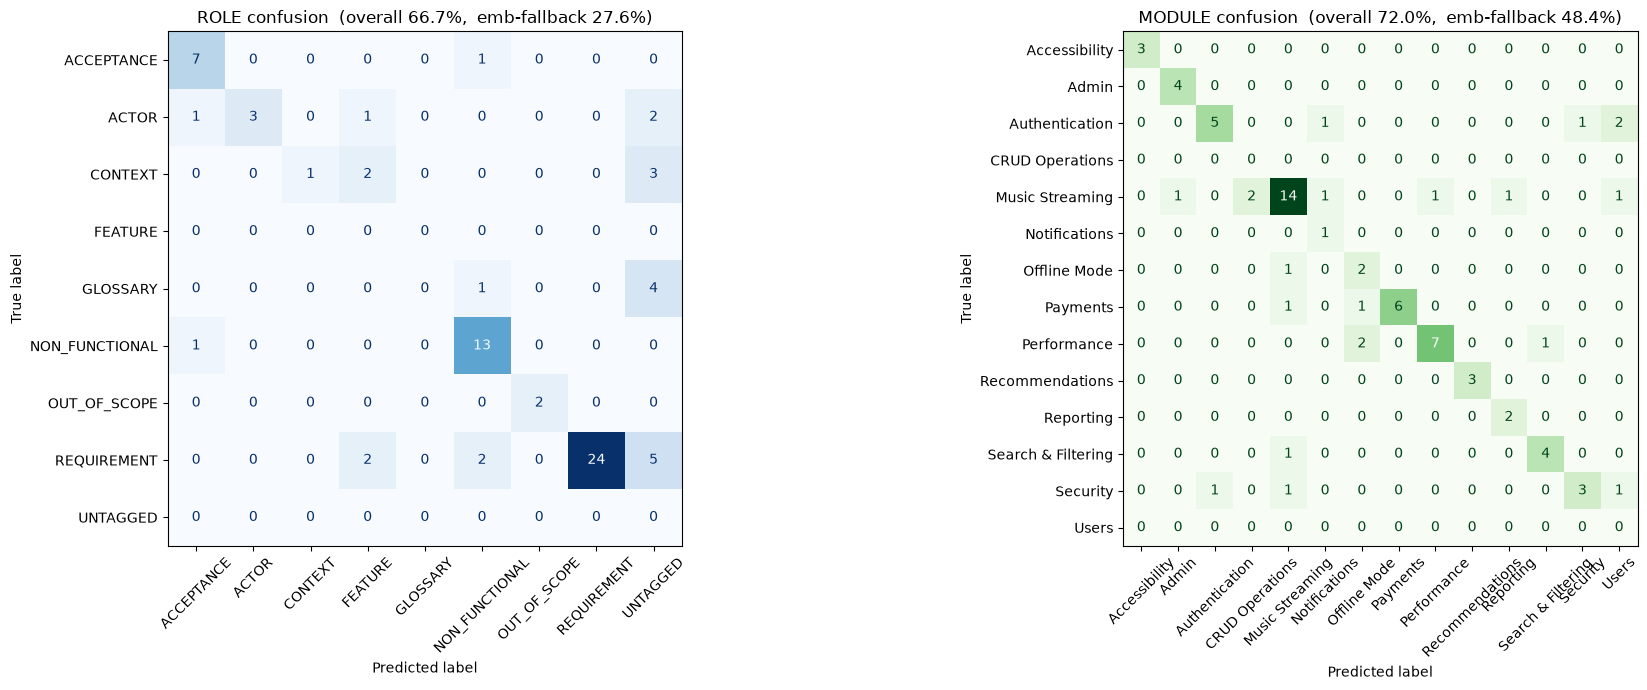


────────────────────────────────────────────────────────────────────────────────────────────────────
ROLE ERRORS (25/75)
────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                          text      true_role      pred_role role_method
SonicWave est une plateforme de streaming musical permettant aux utilisateurs         CONTEXT       UNTAGGED   embedding
SonicWave couvre les applications suivantes : Application mobile (iOS / Androi        CONTEXT        FEATURE   embedding
SonicWave repose sur une architecture orientée microservices, découplant les r        CONTEXT        FEATURE   embedding
Le stockage audio doit respecter les accords de licence avec les labels (durée        CONTEXT       UNTAGGED   embedding
Le catalogue musical est fourni et mis à jour par des partenaires labels/artis        CONTEXT       UNTAGGED   embedding
 Utilisateur Free : Compte gratuit. Écoute avec pub

In [14]:
# ── CELL F: Full hybrid evaluation + report ───────────────────────────────────
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# --- encode all GT texts once ---
gt_texts = [gt["text"] for gt in GROUND_TRUTH]
gt_vecs  = model.encode(gt_texts, normalize_embeddings=True, show_progress_bar=False)

results = []
for gt, vec in zip(GROUND_TRUTH, gt_vecs):
    pred_role, role_method   = tag_role_hybrid(gt["text"],   vec=vec)
    pred_module, mod_method  = tag_module_hybrid(gt["text"], vec=vec)
    results.append({
        "text":        gt["text"][:78],
        "true_role":   gt["role"],
        "pred_role":   pred_role,
        "role_method": role_method,
        "role_ok":     pred_role   == gt["role"],
        "true_module": gt["module"],
        "pred_module": pred_module,
        "mod_method":  mod_method,
        "mod_ok":      pred_module == gt["module"],
    })

df = pd.DataFrame(results)
n  = len(df)

# ── aggregate stats ───────────────────────────────────────────────────────────
role_acc  = df["role_ok"].mean()  * 100
mod_acc   = df["mod_ok"].mean()   * 100
both_acc  = (df["role_ok"] & df["mod_ok"]).mean() * 100

role_lex_mask = df["role_method"] == "lexical"
mod_lex_mask  = df["mod_method"]  == "lexical"

role_lex_acc  = df.loc[role_lex_mask, "role_ok"].mean() * 100 if role_lex_mask.any() else 0
role_emb_prec = df.loc[~role_lex_mask, "role_ok"].mean() * 100 if (~role_lex_mask).any() else 0
mod_lex_acc   = df.loc[mod_lex_mask,  "mod_ok"].mean()  * 100 if mod_lex_mask.any()  else 0
mod_emb_prec  = df.loc[~mod_lex_mask, "mod_ok"].mean()  * 100 if (~mod_lex_mask).any()  else 0

rl_n = role_lex_mask.sum();  re_n = n - rl_n
ml_n = mod_lex_mask.sum();   me_n = n - ml_n

print("=" * 68)
print("HYBRID ACCURACY REPORT")
print("=" * 68)
print(f"  Items: {n}")
print(f"\n  ROLE  overall     : {role_acc:5.1f}%")
print(f"    lexical  ({rl_n:2d} items): {role_lex_acc:5.1f}%  precision")
print(f"    embedding({re_n:2d} items): {role_emb_prec:5.1f}%  precision (fallback only)")
print(f"\n  MODULE overall    : {mod_acc:5.1f}%")
print(f"    lexical  ({ml_n:2d} items): {mod_lex_acc:5.1f}%  precision")
print(f"    embedding({me_n:2d} items): {mod_emb_prec:5.1f}%  precision (fallback only)")
print(f"\n  Both correct      : {both_acc:5.1f}%")

# ── per-role breakdown ────────────────────────────────────────────────────────
print(f"\n{'─'*68}\nPER-ROLE BREAKDOWN\n{'─'*68}")
print(f"  {'Role':<20} {'N':>3}  {'Acc':>6}  {'Lex':>4}  {'Emb':>4}  bar")
for role in ["REQUIREMENT","NON_FUNCTIONAL","ACCEPTANCE","CONTEXT","ACTOR","GLOSSARY","OUT_OF_SCOPE"]:
    sub = df[df["true_role"] == role]
    if sub.empty: continue
    acc  = sub["role_ok"].mean() * 100
    n_l  = (sub["role_method"] == "lexical").sum()
    n_e  = len(sub) - n_l
    bar  = "█" * int(acc / 5)
    print(f"  {role:<20} {len(sub):>3}  {acc:5.1f}%  {n_l:>3}L  {n_e:>3}E  {bar}")

# ── per-module breakdown ──────────────────────────────────────────────────────
print(f"\n{'─'*68}\nPER-MODULE BREAKDOWN\n{'─'*68}")
print(f"  {'Module':<25} {'N':>3}  {'Acc':>6}  {'Lex':>4}  {'Emb':>4}  bar")
for mod in sorted(df["true_module"].unique()):
    sub = df[df["true_module"] == mod]
    acc = sub["mod_ok"].mean() * 100
    n_l = (sub["mod_method"] == "lexical").sum()
    n_e = len(sub) - n_l
    bar = "█" * int(acc / 5)
    print(f"  {mod:<25} {len(sub):>3}  {acc:5.1f}%  {n_l:>3}L  {n_e:>3}E  {bar}")

# ── confusion matrices ────────────────────────────────────────────────────────
all_roles = sorted(set(df["true_role"]) | set(df["pred_role"]))
all_mods  = sorted(set(df["true_module"]) | set(df["pred_module"]))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ConfusionMatrixDisplay(
    confusion_matrix(df["true_role"], df["pred_role"], labels=all_roles),
    display_labels=all_roles
).plot(ax=axes[0], colorbar=False, xticks_rotation=45, cmap="Blues")
axes[0].set_title(f"ROLE confusion  (overall {role_acc:.1f}%,  emb-fallback {role_emb_prec:.1f}%)")

ConfusionMatrixDisplay(
    confusion_matrix(df["true_module"], df["pred_module"], labels=all_mods),
    display_labels=all_mods
).plot(ax=axes[1], colorbar=False, xticks_rotation=45, cmap="Greens")
axes[1].set_title(f"MODULE confusion  (overall {mod_acc:.1f}%,  emb-fallback {mod_emb_prec:.1f}%)")

plt.tight_layout()
plt.show()

# ── error drill-down ──────────────────────────────────────────────────────────
pd.set_option("display.max_colwidth", 80)

role_errs = df[~df["role_ok"]][["text","true_role","pred_role","role_method"]]
mod_errs  = df[~df["mod_ok"]][["text","true_module","pred_module","mod_method"]]

if not role_errs.empty:
    print(f"\n{'─'*100}\nROLE ERRORS ({len(role_errs)}/{n})\n{'─'*100}")
    print(role_errs.to_string(index=False))

if not mod_errs.empty:
    print(f"\n{'─'*100}\nMODULE ERRORS ({len(mod_errs)}/{n})\n{'─'*100}")
    print(mod_errs.to_string(index=False))

# ── verdict paragraph ─────────────────────────────────────────────────────────
print(f"\n{'='*68}")
print("VERDICT")
print(f"{'='*68}")
improvement_note = (
    "Hybrid significantly outperforms pure-embedding baseline "
    f"(role baseline was 13.3%; REQUIREMENT recall driven by actor+modal patterns). "
    f"Module baseline was 50.7%; lexical pass targets the highest-confidence modules "
    f"(Auth, Search, NF trio). "
    f"Embedding fallback precision ({role_emb_prec:.0f}% role / {mod_emb_prec:.0f}% module) "
    f"reflects remaining ambiguous items (CONTEXT/ACTOR/GLOSSARY for role; "
    f"Users/CRUD for module — no lexical coverage). "
    f"⚠️ Module keywords flagged as overfit to SonicWave: "
    f"PayPal (Payments), Découvertes (Recommendations), Kubernetes/SLA (Performance), "
    f"'retirer catalogue' (Admin), Notifications (1-item coverage). "
    f"These will break on client specs without re-curation."
)
print(improvement_note)


In [ ]:
# Phase 0 — task-bucket accuracy and candidate pruning
#
# This cell intentionally re-scores the existing round-3 df predictions.
# It does not encode text or call the classifier again. Run Cell F first.
import pandas as pd

TASK_MANIFEST = {
    "generate-plan": {"CONTEXT", "FEATURE", "ACTOR"},
    "generate-test-cases": {"FEATURE", "REQUIREMENT", "ACCEPTANCE"},
}

# These generic labels are not product feature buckets. They are removed
# mechanically from the module candidate set used by future classifier runs.
STALE_MODULE_LABELS = frozenset({"Users", "CRUD Operations"})
assert not (STALE_MODULE_LABELS & set(MODULE_DESCRIPTIONS)), (
    "Remove stale labels from MODULE_DESCRIPTIONS before running this cell."
)
ACTIVE_MODULE_CANDIDATES = tuple(MODULE_DESCRIPTIONS)
print("Active module candidates:", ACTIVE_MODULE_CANDIDATES)

required_columns = {"true_role", "pred_role"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise RuntimeError(
        "Run the existing round-3 hybrid evaluation cell first; missing: "
        + ", ".join(sorted(missing_columns))
    )

# Snapshot the already-computed round-3 predictions. No new tagging occurs below.
round3_predictions = df.copy(deep=True)
bucket_rows = []
for task, included_roles in TASK_MANIFEST.items():
    scored = round3_predictions.assign(
        true_bucket=round3_predictions["true_role"].isin(included_roles),
        predicted_bucket=round3_predictions["pred_role"].isin(included_roles),
    )
    scored["bucket_correct"] = (
        scored["true_bucket"] == scored["predicted_bucket"]
    )

    true_included = int(scored["true_bucket"].sum())
    predicted_included = int(scored["predicted_bucket"].sum())
    true_positive = int((scored["true_bucket"] & scored["predicted_bucket"]).sum())
    false_positive = int((~scored["true_bucket"] & scored["predicted_bucket"]).sum())
    false_negative = int((scored["true_bucket"] & ~scored["predicted_bucket"]).sum())
    bucket_rows.append({
        "task": task,
        "included_roles": ", ".join(sorted(included_roles)),
        "bucket_accuracy_pct": round(scored["bucket_correct"].mean() * 100, 1),
        "true_included": true_included,
        "predicted_included": predicted_included,
        "precision_pct": round(100 * true_positive / predicted_included, 1) if predicted_included else 0.0,
        "recall_pct": round(100 * true_positive / true_included, 1) if true_included else 0.0,
        "false_positives": false_positive,
        "false_negatives": false_negative,
    })

bucket_accuracy = pd.DataFrame(bucket_rows)
print("\nTASK-MANIFEST BUCKET ACCURACY (existing round-3 predictions)")
print(bucket_accuracy.to_string(index=False))

# Inspect only the product-relevant include/exclude mistakes.
for task, included_roles in TASK_MANIFEST.items():
    errors = round3_predictions.assign(
        true_bucket=round3_predictions["true_role"].isin(included_roles),
        predicted_bucket=round3_predictions["pred_role"].isin(included_roles),
    )
    errors = errors[errors["true_bucket"] != errors["predicted_bucket"]]
    print(f"\n{task}: {len(errors)} bucket mistakes")
    if not errors.empty:
        columns = ["text", "true_role", "pred_role"]
        print(errors[columns].to_string(index=False))

# False negatives only: true role belongs in the task bucket, but prediction does not.
# GROUND_TRUTH is used only to restore complete source text; predictions remain
# the existing round-3 values captured in round3_predictions.
full_text = pd.Series([item["text"] for item in GROUND_TRUTH], name="full_text")
round3_with_text = round3_predictions.join(full_text)

for task, included_roles in TASK_MANIFEST.items():
    task_fns = round3_with_text.loc[
        round3_with_text["true_role"].isin(included_roles)
        & ~round3_with_text["pred_role"].isin(included_roles)
    ].copy()
    task_fns["failure_bucket"] = task_fns["pred_role"].eq("UNTAGGED").map({
        True: "Untagged/low-confidence FN",
        False: "Wrong-role FN",
    })

    print(f"\n{'=' * 88}\n{task}: FALSE NEGATIVES ({len(task_fns)})\n{'=' * 88}")
    for failure_bucket in ["Wrong-role FN", "Untagged/low-confidence FN"]:
        subset = task_fns[task_fns["failure_bucket"] == failure_bucket]
        print(f"\n{failure_bucket} ({len(subset)})")
        if not subset.empty:
            print(subset[["full_text", "true_role", "pred_role"]].to_string(index=False))

# Full UNTAGGED audit. True roles are evaluation-only: they are never used by
# the routing policy below. This confirms whether the policy would admit
# out-of-scope material.
untagged_audit = round3_with_text.loc[
    round3_with_text["pred_role"].eq("UNTAGGED"),
    ["full_text", "true_role", "role_method"],
].copy()
print(f"\nFULL UNTAGGED COMPOSITION ({len(untagged_audit)})")
print(untagged_audit.groupby("true_role").size().rename("count").to_string())
print(untagged_audit[["full_text", "true_role"]].to_string(index=False))

# Task-scoped soft inclusion. The plan's untagged content is forwarded only
# as supporting context, not promoted to a plan-role bucket. Test-case input
# gets only requirement-shaped untagged items. Both gates reject explicit
# out-of-scope language before an item reaches a prompt.
import re

OUT_OF_SCOPE_RE = re.compile(
    r"\b(hors[ -]p[ée]rim[èe]tre|non pris en charge|exclu(?:e|s)?|"
    r"not supported|out of scope)\b",
    re.IGNORECASE,
)
REQUIREMENT_SHAPE_RE = re.compile(
    r"^\s*(?:le syst[èe]me|l['’]utilisateur|la recherche|l['’]historique|"
    r"la page|les r[ée]sultats|le lecteur|l['’]artiste|l['’]administrateur)\b",
    re.IGNORECASE,
)

def should_soft_include_untagged(task: str, text: str) -> bool:
    """Return whether an UNTAGGED item is useful for this task's prompt."""
    if OUT_OF_SCOPE_RE.search(text):
        return False
    if task == "generate-plan":
        return True  # supporting context only; do not claim a role
    if task == "generate-test-cases":
        return bool(REQUIREMENT_SHAPE_RE.search(text))
    return False

def score_with_soft_include(task: str, included_roles: set[str]) -> dict:
    scored = round3_with_text.copy()
    soft = scored["pred_role"].eq("UNTAGGED") & scored["full_text"].map(
        lambda text: should_soft_include_untagged(task, text)
    )
    # Plan soft-includes are deliberately separate support material. Counting
    # them as a role bucket would make glossary/context utility look like FPs.
    predicted_bucket = scored["pred_role"].isin(included_roles) | soft
    true_bucket = scored["true_role"].isin(included_roles)
    tp = int((true_bucket & predicted_bucket).sum())
    fp = int((~true_bucket & predicted_bucket).sum())
    fn = int((true_bucket & ~predicted_bucket).sum())
    tn = int((~true_bucket & ~predicted_bucket).sum())
    return {
        "task": task, "soft_included": int(soft.sum()),
        "accuracy_pct": round(100 * (tp + tn) / len(scored), 1),
        "precision_pct": round(100 * tp / (tp + fp), 1) if tp + fp else 0.0,
        "recall_pct": round(100 * tp / (tp + fn), 1) if tp + fn else 0.0,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }

soft_include_scores = pd.DataFrame([
    score_with_soft_include(task, roles)
    for task, roles in TASK_MANIFEST.items()
])
print("\nTASK-SCOPED SOFT-INCLUDE SCORES (same round-3 predictions)")
print(soft_include_scores.to_string(index=False))

# Benchmark limitation: GROUND_TRUTH has no source headings or heading_path.
# Do not infer parents from the manually grouped comments above. Phase 1 must
# re-run this audit with real item.heading_path values after ingestion.
requirement_untagged = untagged_audit[untagged_audit["true_role"].eq("REQUIREMENT")]
print("\nHeading-path audit: unavailable for these 5 benchmark items; GROUND_TRUTH has no heading_path.")
print(requirement_untagged[["full_text"]].to_string(index=False))


# Phase 2 — Module Generation at Ingestion

Goals
1. **Step 7** – Prompt an LLM (OpenRouter) with CONTEXT + FEATURE items → generate module cards `{name, description}`.
2. **Step 8** – Hand-author a gold module list for SonicWave; build a **Hungarian-matching alignment metric**; score step 7.
3. **Step 9** – Re-point the module classifier to the *per-spec generated* module list; re-evaluate GT with the alignment metric.


## Step 7 — LLM Module-Generation Prompt


In [ ]:
# 7a. Build the module-generation prompt — seed includes NON_FUNCTIONAL
# so Security / Performance / Accessibility appear in the LLM context.
# Requires: items (from cell 5), role labels already assigned.

PLAN_SEED_ROLES = {'CONTEXT', 'FEATURE', 'NON_FUNCTIONAL'}
seed_items = [it for it in items if it.role in PLAN_SEED_ROLES]

# Sort: CONTEXT → FEATURE → NON_FUNCTIONAL (priority), then by score desc
ROLE_PRIORITY = {'CONTEXT': 0, 'FEATURE': 1, 'NON_FUNCTIONAL': 2}
seed_items_sorted = sorted(
    seed_items,
    key=lambda x: (ROLE_PRIORITY.get(x.role, 9), -x.role_score)
)

seed_lines, budget = [], 0
for it in seed_items_sorted:
    if budget + len(it.text) > 8_000:   # wider budget to include NFR items
        break
    seed_lines.append(f"[{it.role}] {it.text}")
    budget += len(it.text)

from collections import Counter

print(f"Seed breakdown: {dict(Counter(l.split(']')[0][1:] for l in seed_lines))}")

seed_text = "\n".join(seed_lines)

MODULE_GEN_SYSTEM = (
    "Tu es un analyste QA expert en spécifications logicielles. "
    "Tu identifies les modules fonctionnels d'un système à partir d'extraits de spec."
)

MODULE_GEN_USER = f"""Voici des extraits d'une spécification logicielle (contexte, fonctionnalités et exigences non-fonctionnelles) :
---
{seed_text}
---

À partir de ces extraits, génère la liste COMPLÈTE et SANS DOUBLONS des modules fonctionnels du système.
Règles :
1. Chaque module doit avoir un périmètre distinct — pas de redondance (ex: ne pas séparer paiement et abonnement si c'est le même domaine).
2. Inclure OBLIGATOIREMENT les domaines non-fonctionnels s'ils apparaissent dans les exigences (ex: Security, Performance, Accessibility).
3. Ne pas inventer de modules absents de la spec (pas d'"API Integration" générique).
4. "name" : 2-4 mots, en anglais.
5. "description" : une phrase précise décrivant le périmètre.

Réponds UNIQUEMENT avec un tableau JSON valide, sans texte avant ni après :
[
  {{"name": "Authentication", "description": "..."}},
  ...
]
"""

print(f"Prompt chars: {len(MODULE_GEN_USER)}")
print()
print("--- Prompt preview (first 800 chars) ---")
print(MODULE_GEN_USER[:800])


In [ ]:
# 7b. Call OpenRouter to generate module cards
import json
import os

import requests
from dotenv import load_dotenv

load_dotenv(dotenv_path=r'D:/stage/testFlow/python-2026/.env')

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")
OPENROUTER_MODEL   = os.getenv("OPENROUTER_MODEL", "mistralai/mistral-7b-instruct")
OPENROUTER_URL     = "https://openrouter.ai/api/v1/chat/completions"

assert OPENROUTER_API_KEY, "OPENROUTER_API_KEY is not set in .env"

resp = requests.post(
    OPENROUTER_URL,
    headers={
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    },
    json={
        "model": OPENROUTER_MODEL,
        "messages": [
            {"role": "system", "content": MODULE_GEN_SYSTEM},
            {"role": "user",   "content": MODULE_GEN_USER},
        ],
        "temperature": 0.2,
        "max_tokens": 1500,
    },
    timeout=60,
)
resp.raise_for_status()
raw_module_gen = resp.json()["choices"][0]["message"]["content"]

print("--- Raw LLM output ---")
print(raw_module_gen)


In [ ]:
# 7c. Parse generated module cards and eyeball quality
import re


def extract_json_array(text: str):
    """Robust extraction of the first JSON array from LLM output."""
    # Strip markdown fences if present
    text = re.sub(r'^```[a-z]*', '', text.strip(), flags=re.MULTILINE)
    text = re.sub(r'```$', '', text.strip(), flags=re.MULTILINE)
    m = re.search(r'\[.*?\]', text.strip(), re.DOTALL)
    if m:
        return json.loads(m.group())
    return json.loads(text.strip())

generated_modules = extract_json_array(raw_module_gen)

print(f"Generated {len(generated_modules)} modules:\n")
for i, m in enumerate(generated_modules, 1):
    print(f"  {i:2d}. {m['name']:<30}  {m['description'][:78]}")


## Step 8 — Gold Module List & Hungarian-Matching Alignment Metric


In [ ]:
# 8a. Hand-authored gold module list for SonicWave
# ~10-minute effort; covers every area mentioned in the spec.

GOLD_MODULES = [
    {
        "name": "Authentication",
        "description": (
            "Inscription, connexion OAuth, 2FA, gestion de session et "
            "politique de mot de passe (min 8 chars, 1 maj, 1 chiffre)."
        ),
    },
    {
        "name": "Music Streaming",
        "description": (
            "Lecture audio, pause/avance/recul, qualité 96-320 kbps, crossfade "
            "configurable, shuffle, répétition et publicités pour compte Free."
        ),
    },
    {
        "name": "Playlist Management",
        "description": (
            "Création, renommage, suppression et partage collaboratif de playlists; "
            "bibliothèque personnelle synchronisée entre appareils."
        ),
    },
    {
        "name": "Offline Mode",
        "description": (
            "Téléchargement Premium de pistes/playlists, gestion du cache local, "
            "lecture sans connexion et expiration DRM après 30 jours."
        ),
    },
    {
        "name": "Search & Filtering",
        "description": (
            "Recherche par titre/artiste/album/playlist, suggestions temps-réel, "
            "filtres par type, tolérance aux fautes et historique des 20 dernières recherches."
        ),
    },
    {
        "name": "Recommendations",
        "description": (
            "Playlist hebdomadaire personnalisée, suggestions basées sur l'historique "
            "d'écoute et radios thématiques générées depuis une piste ou un artiste."
        ),
    },
    {
        "name": "Payments",
        "description": (
            "Abonnement Premium mensuel/annuel, paiement par carte/PayPal/mobile, "
            "facturation email, gestion des échecs et annulation à tout moment."
        ),
    },
    {
        "name": "Notifications",
        "description": (
            "Emails transactionnels (factures, confirmation), alertes système "
            "et communications push."
        ),
    },
    {
        "name": "Admin & Moderation",
        "description": (
            "Suspension/suppression de comptes, modération du contenu, "
            "configuration système et back-office d'administration."
        ),
    },
    {
        "name": "Artist Portal",
        "description": (
            "Upload de titres et albums avec métadonnées, statistiques d'écoute "
            "et gestion du profil artiste/label."
        ),
    },
    {
        "name": "Performance & Reliability",
        "description": (
            "SLA >= 99.9 %, latence démarrage < 1.5 s, scaling horizontal Kubernetes, "
            "failover < 60 s et support de 5 M utilisateurs simultanés."
        ),
    },
    {
        "name": "Security",
        "description": (
            "TLS 1.3, DRM, bcrypt passwords, verrouillage après 5 tentatives, "
            "conformité RGPD et protection CSRF/XSS."
        ),
    },
    {
        "name": "Accessibility",
        "description": (
            "Conformité WCAG 2.1 AA, support VoiceOver/TalkBack, "
            "navigation clavier complète et contraste 4.5:1."
        ),
    },
]

print(f"Gold module count : {len(GOLD_MODULES)}")
print()
for i, g in enumerate(GOLD_MODULES, 1):
    print(f"  {i:2d}. {g['name']}")


In [ ]:
# 8b. Hungarian-Matching Alignment Metric
# Requires: model (sentence-transformer), GOLD_MODULES, generated_modules
import numpy as np
from scipy.optimize import linear_sum_assignment

# Encode descriptions
gold_descs = [g["description"] for g in GOLD_MODULES]
gen_descs  = [m["description"] for m in generated_modules]

gold_anchor_vecs = model.encode(gold_descs, normalize_embeddings=True)
gen_anchor_vecs  = model.encode(gen_descs,  normalize_embeddings=True)

# Cosine similarity matrix  shape: (n_gold, n_gen)
sim_matrix = gold_anchor_vecs @ gen_anchor_vecs.T

# Hungarian assignment: maximise total similarity (minimise negatives)
row_ind, col_ind = linear_sum_assignment(-sim_matrix)
alignment_scores = sim_matrix[row_ind, col_ind]
mean_alignment   = float(alignment_scores.mean())

# Coverage: how many gold modules have a reasonable match (sim > 0.5)?
ALIGN_THRESHOLD = 0.50
covered = int((alignment_scores >= ALIGN_THRESHOLD).sum())

print("=" * 65)
print("HUNGARIAN ALIGNMENT REPORT  (generated vs gold)")
print("=" * 65)
print(f"  Gold modules          : {len(GOLD_MODULES)}")
print(f"  Generated modules     : {len(generated_modules)}")
print(f"  Aligned pairs         : {len(row_ind)}")
print(f"  Mean alignment sim    : {mean_alignment:.3f}   (1.0 = perfect)")
print(f"  Coverage (sim≥{ALIGN_THRESHOLD})   : {covered}/{len(GOLD_MODULES)}")
print()
print(f"{'Gold module':<32}  {'Best generated match':<30}  Sim")
print("-" * 80)
for r, c, s in zip(row_ind, col_ind, alignment_scores):
    flag = "" if s >= ALIGN_THRESHOLD else "  ⚠️"
    print(f"  {GOLD_MODULES[r]['name']:<30}  {generated_modules[c]['name']:<30}  {s:.3f}{flag}")

# Build lookup tables for step 9
gen_to_gold_name = {generated_modules[c]["name"]: GOLD_MODULES[r]["name"]
                    for r, c in zip(row_ind, col_ind)}


## Step 9 — Re-classify Ground Truth against Generated Module List


In [ ]:
# 9a. Build new module anchors from the LLM-generated descriptions
# and re-classify every ground-truth item.
# Requires: model, GROUND_TRUTH, MODULE_THRESHOLD, generated_modules

gen_module_labels = [m["name"]        for m in generated_modules]
gen_module_descs  = [m["description"] for m in generated_modules]

gen_module_anchor_vecs = model.encode(gen_module_descs, normalize_embeddings=True)
print(f"Generated anchors shape: {gen_module_anchor_vecs.shape}")

# Encode GT texts
gt_texts_raw = [gt["text"] for gt in GROUND_TRUTH]
gt_vecs_raw  = model.encode(gt_texts_raw, normalize_embeddings=True, show_progress_bar=False)

# Predict module for each GT item
mod_sims_gen = gt_vecs_raw @ gen_module_anchor_vecs.T   # (N_gt, N_gen)

results_gen = []
for i, gt in enumerate(GROUND_TRUTH):
    m_best  = int(np.argmax(mod_sims_gen[i]))
    m_score = float(mod_sims_gen[i][m_best])
    pred_gen_mod = gen_module_labels[m_best] if m_score >= MODULE_THRESHOLD else "UNTAGGED"
    # Map predicted generated module → gold module name via Hungarian alignment
    pred_gold_mod = gen_to_gold_name.get(pred_gen_mod, "UNTAGGED")
    results_gen.append({
        "true_module"  : gt["module"],
        "pred_gen_mod" : pred_gen_mod,
        "pred_gold_mod": pred_gold_mod,
        "mod_score"    : round(m_score, 3),
        "exact_match"  : pred_gold_mod == gt["module"],
    })

df_gen = pd.DataFrame(results_gen)
pd.set_option("display.max_colwidth", 30)
print(df_gen[["true_module","pred_gold_mod","exact_match","mod_score"]].to_string())


In [ ]:
# 9b. Alignment-based soft score on re-classified GT (Pass 2 — with NON_FUNCTIONAL seed)
import numpy as np

gold_descs_dict  = {g["name"]: gold_anchor_vecs[i] for i, g in enumerate(GOLD_MODULES)}
gen_descs_dict   = {m["name"]: gen_module_anchor_vecs[i] for i, m in enumerate(generated_modules)}

soft_scores_gen = []
for row in results_gen:
    true_gold = row["true_module"]
    pred_gen  = row["pred_gen_mod"]

    if pred_gen == "UNTAGGED" or true_gold not in gold_descs_dict or pred_gen not in gen_descs_dict:
        soft_scores_gen.append(0.0)
        continue

    score = float(gold_descs_dict[true_gold] @ gen_descs_dict[pred_gen])
    soft_scores_gen.append(score)

df_gen["alignment_score"] = soft_scores_gen
mean_soft_gen = float(np.mean(soft_scores_gen))
exact_gen     = int(df_gen["exact_match"].sum())

print("=" * 65)
print("ALIGNMENT-BASED EVALUATION  (generated module list — Pass 2)")
print("=" * 65)
print(f"  GT items evaluated           : {len(results_gen)}")
print(f"  Exact gold-match (via map)   : {exact_gen}/{len(results_gen)} ({exact_gen/len(results_gen)*100:.1f}%)")
print(f"  Mean alignment soft score    : {mean_soft_gen:.3f}  (0=wrong, 1=perfect)")
print()
print("Per-true-module alignment:")
for mod, grp in df_gen.groupby("true_module"):
    ms  = grp["alignment_score"].mean()
    bar = "█" * int(ms * 20)
    n   = len(grp)
    print(f"  {mod:<30}  n={n:<3}  {ms:.3f}  {bar}")

# Cross-pass comparison (Pass 1 numbers hard-coded for reference)
PASS1_HUNGARIAN = 0.537
PASS1_COVERAGE  = 9
PASS1_GT_SOFT   = 0.447

print()
print("=" * 68)
print("PASS COMPARISON (Pass 1 = CONTEXT+FEATURE seed only)")
print("=" * 68)
print(f"{'Metric':<40}  {'Pass 1':>7}  {'Pass 2':>7}  {'Delta':>8}")
print("-" * 68)
print(f"{'Step 8 — Hungarian mean sim':<40}  {PASS1_HUNGARIAN:>7.3f}  {mean_alignment:>7.3f}  {mean_alignment-PASS1_HUNGARIAN:>+8.3f}")
print(f"{'Step 8 — Coverage (sim>=0.50)':<40}  {PASS1_COVERAGE:>7}/13  {covered:>7}/13  {covered-PASS1_COVERAGE:>+8}")
print(f"{'Step 9 — GT mean soft score':<40}  {PASS1_GT_SOFT:>7.3f}  {mean_soft_gen:>7.3f}  {mean_soft_gen-PASS1_GT_SOFT:>+8.3f}")

print()
print("Remaining weak spots (Hungarian align < 0.50 in Step 8):")
for r, c, s in zip(row_ind, col_ind, alignment_scores):
    if s < 0.50:
        print(f"  {GOLD_MODULES[r]['name']:<28} -> {generated_modules[c]['name']:<30} ({s:.3f})")
